---
downloads: []
---

(sec:linear_systems)=

# Linear Systems

Lots of problems in natural sciences, engineering, and beyond can be described
by systems of linear equations. You have already seen systems with a unique
solution in introductory mathematics courses. In real data analysis, however,
we often encounter systems with no exact solution or infinitely many solutions.
In this section, we shall learn how to handle these two cases.

## Theoretical Foundations

A linear system has the form

```{math}
:enumerated: true
:label: eq:linear-system
\bm{A}\vec{x} = \vec{b}\,.
```

The matrix $\bm{A} \in \mathbb{R}^{m \times n}$ contains the coefficients of the
system. The vector $\vec{x} \in \mathbb{R}^n$ contains the unknowns, and
$\vec{b} \in \mathbb{R}^m$ is the right-hand side vector, also referred to
as the inhomogeneity.
The number $m$ is the number of equations, and $n$ is the number of unknowns.

If $m=n$ and $\bm{A}$ is invertible, the system has the unique solution
$\vec{x}=\bm{A}^{-1}\vec{b}$. Most real data problems are less tidy: we may have
more equations than unknowns, fewer equations than unknowns, or equations that
are partly redundant.

### Determinacy of Linear Systems

A first useful classification is based on the number of equations $m$ and the
number of unknowns $n$:

- $m = n$: There are exactly as many equations as unknowns.
  Usually, the system has a unique solution and is called *determined*.
- $m > n$: There are more equations than unknowns. 
  Usually, the system has no exact solution and is called *overdetermined*.
- $m < n$: There are fewer equations than unknowns. 
  Usually, the system has infinitely many solutions and is called
  *underdetermined*.

The word "usually" matters because some equations can be redundant, and some
systems can be inconsistent. A more rigorous classification uses the
rank of $\bm{A}$, which we already encountered in 
Sec.&nbsp;[](#sec:singular_value_decomposition). The rank tells us how
many linearly independent equations are present after redundant equations have
been removed.

:::{note} Rank and determinacy
:class: dropdown
Let
$$
p = \operatorname{rank}(\bm{A})
$$
be the number of linearly independent equations. Since there are only $m$ rows
and $n$ columns, we always have $p \leq \min(m,n)$.

To decide whether an exact solution exists, we also have to check whether the
right-hand side $\vec{b}$ is compatible with these equations. This can be done
with the rank of the augmented matrix $[\bm{A}\,|\,\vec{b}]$:

- If $\operatorname{rank}(\bm{A}) \neq \operatorname{rank}([\bm{A}\,|\,\vec{b}])$,
  the system is inconsistent and has no exact solution.
- If $\operatorname{rank}(\bm{A}) = \operatorname{rank}([\bm{A}\,|\,\vec{b}]) = n$,
  the system has a unique exact solution.
- If $\operatorname{rank}(\bm{A}) = \operatorname{rank}([\bm{A}\,|\,\vec{b}]) < n$,
  the system has infinitely many exact solutions.
:::

### Moore-Penrose Pseudoinverse

For a determined system, the solution can be written as $\vec{x}=\bm{A}^{-1}\vec{b}$,
where $\bm{A}^{-1}$ is the inverse of $\bm{A}$. This inverse is only defined for
square, invertible matrices. For overdetermined and underdetermined systems, we
need a more general tool: the [*Moore&ndash;Penrose pseudoinverse*](wiki:Moore-Penrose_inverse)
(MP inverse), written $\bm{A}^{+}$. It is defined for every matrix.

Using the singular value decomposition $\bm{A}=\bm{U}\bm{\Sigma}\bm{V}^\intercal$,
we can compute the MP inverse as

```{math}
:enumerated: true
:label: eq:pseudoinverse-definition
\bm{A}^{+}=\bm{V}\bm{\Sigma}^{+}\bm{U}^\intercal\,.
```
The matrix $\bm{\Sigma}^{+}$ is obtained from $\bm{\Sigma}$ by transposing its
shape and replacing every non-zero singular value $\sigma_i$ by
$1/\sigma_i$. Singular values that are zero are kept at zero.
If $\bm{A}$ is invertible, $\bm{A}^{+}$ coincides with $\bm{A}^{-1}$.

The formal definition is given by the

:::{note} Moore-Penrose Conditions
:class: dropdown
The Moore-Penrose pseudoinverse is the unique matrix $\bm{A}^{+}$ that satisfies
four conditions:
```{math}
:enumerated: true
:label: eq:mp_conditions
\begin{align}
  \bm{A}\bm{A}^{+}\bm{A} &= \bm{A} \\
  \bm{A}^{+}\bm{A}\bm{A}^{+} &= \bm{A}^{+} \\
  (\bm{A}\bm{A}^{+})^\intercal &= \bm{A}\bm{A}^{+} \\
  (\bm{A}^{+}\bm{A})^\intercal &= \bm{A}^{+}\bm{A}
\end{align}
```
:::

The MP inverse gives one compact expression for both cases we care about:

```{math}
:enumerated: true
:label: eq:pseudoinverse-solution
\vec{x}_0 = \bm{A}^{+}\vec{b}\,.
```

For an overdetermined system, $\bm{A}^{+}\vec{b}$ gives a least-squares solution:
$$
  \vec{x}_0 := \bm{A}^+ \vec{b} \in \argmin_{\vec{x}\in \mathbb{R}^n} \| \bm{A} \vec{x} - \vec{b} \|_2^2\,.
$$
*i.e.*, $\vec{x}_0$ minimises the quadratic error between both sides of the
system. If several vectors have the same least-squares error, $\vec{x}_0$ is
the one with the smallest Euclidean norm.

:::{tip} Proof
:class: dropdown
Let $\vec{x} \in \mathbb{R}^n$ be an arbitrary vector.
Then

$$
\begin{align*}
  \|\bm{A} \vec{x} - \vec{b}\|_2^2 &= \| \bm{A} (\vec{x} - \vec{x}_0) + (\bm{A} \vec{x}_0 - \vec{b}) \|_2^2 \\
    &= \|\bm{A}(\vec{x} - \vec{x}_0)\|_2^2 + \|\bm{A}\vec{x}_0 - \vec{b}\|_2^2  
    + 2 \left(\vec{x} - \vec{x}_0\right)^\intercal \bm{A}^\intercal \left(\bm{A}\vec{x}_0 - \vec{b}\right) \\
    &\geq \|\bm{A}\vec{x}_0 - \vec{b}\|_2^2 + 2 \left(\vec{x} - \vec{x}_0\right)^\intercal \bm{A}^\intercal \left(\bm{A}\vec{x}_0 - \vec{b}\right)\,.
\end{align*}
$$

Moreover, 

$$
\begin{align*}
    \bm{A}^\intercal \left(\bm{A}\vec{x}_0 - \vec{b}\right) &= \bm{A}^\intercal \bm{A} \vec{x}_0 - \bm{A}^\intercal \vec{b} \\
    &= \bm{A}^\intercal \bm{A} \bm{A}^+ \vec{b} - \bm{A}^\intercal \vec{b} \\
    &= \bm{A}^\intercal \left(\bm{A} \bm{A}^+\right)^\intercal \vec{b} - \bm{A}^\intercal \vec{b} \\
    &= \left(\bm{A} \bm{A}^+ \bm{A}\right)^\intercal \vec{b} - \bm{A}^\intercal \vec{b} \\
    &= \bm{A}^\intercal \vec{b} - \bm{A}^\intercal \vec{b} = 0
\end{align*}
$$

by inserting the Moore-Penrose conditions. Thus, we have

$$
  \|\bm{A} \vec{x} - \vec{b}\|_2^2 \geq \|\bm{A}\vec{x}_0 - \vec{b}\|_2^2
$$

for all $\vec{x} \in \mathbb{R}^n$. 
In other words, $\vec{x}_0$ minimises the quadratic error between both sides of the system.
:::

For an underdetermined and consistent system, we have
$$
  \vec{x}_0 := \bm{A}^+ \vec{b} \in \argmin_{\bm{A}\vec{x}=\vec{b}} \| \vec{x} \|_2\,
$$
*i.e.*, $\vec{x}_0$ provides the solution with the smallest Euclidean norm.

:::{tip} Proof
:class: dropdown
Let $\vec{x} \in \mathbb{R}^n$ be an arbitrary solution of the system, *i.e.*, $\bm{A}\vec{x}=\vec{b}$.
Then

$$
\begin{align*}
  \|\vec{x}\|_2^2 &= \|\vec{x} - \vec{x}_0 + \vec{x}_0\|_2^2 \\
    &= \|\vec{x} - \vec{x}_0\|_2^2 + \|\vec{x}_0\|_2^2 + 2 \left(\vec{x} - \vec{x}_0\right)^\intercal \vec{x}_0 \\
    &\geq \|\vec{x}_0\|_2^2 + 2 \left(\vec{x} - \vec{x}_0\right)^\intercal \vec{x}_0\,.
\end{align*}
$$

Moreover,

$$
\begin{align*}
    \left(\vec{x} - \vec{x}_0\right)^\intercal \vec{x}_0 
    &= \left(\vec{x} - \bm{A}^+ \vec{b}\right)^\intercal \bm{A}^+ \vec{b} \\
    &= \left(\vec{x} - \bm{A}^+ \bm{A} \vec{x}\right)^\intercal \bm{A}^+ \bm{A} \vec{x} \\
    &= \vec{x}^\intercal \bm{A}^+ \bm{A} \vec{x} - \vec{x}^\intercal \left(\bm{A}^+ \bm{A}\right)^\intercal \bm{A}^+ \bm{A} \vec{x} \\
    &= \vec{x}^\intercal \bm{A}^+ \bm{A} \vec{x} - \vec{x}^\intercal \bm{A}^+ \bm{A} \bm{A}^+ \bm{A} \vec{x} \\
    &= \vec{x}^\intercal \bm{A}^+ \bm{A} \vec{x} - \vec{x}^\intercal \bm{A}^+ \bm{A} \vec{x} \\
    &= 0
\end{align*}
$$

by inserting the Moore-Penrose conditions. Thus, we have

$$
\|\vec{x}\|_2^2 \geq \|\vec{x}_0\|_2^2
$$

for all $\vec{x} \in \mathbb{R}^n$ with $\bm{A}\vec{x}=\vec{b}$.
In other words, $\vec{x}_0$ provides the solution with the smallest Euclidean norm.
:::

## Implementation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

We implement the MP inverse following Eq.&nbsp;[](#eq:pseudoinverse-definition). The idea is to compute the SVD of the input matrix, invert the non-zero singular values, and multiply the matrices back together in the order $\bm{V}\bm{\Sigma}^+\bm{U}^\intercal$.


In [2]:
def mp_inverse(a, rcond=1e-12):
    u, s, vt = np.linalg.svd(a, full_matrices=False)
    cutoff = rcond * s[0]
    
    s_inv = np.zeros_like(s)
    for i, val in enumerate(s):
        if val > cutoff:
            s_inv[i] = 1.0 / val

    return vt.T @ np.diag(s_inv) @ u.T

The function first computes the reduced SVD with `np.linalg.svd(a, full_matrices=False)`. NumPy returns `u`, the singular values `s`, and `vt`, where `vt` is $\bm{V}^\intercal$. Since the singular values are returned as a 
one-dimensional array, we create another array `s_inv` with the same shape and fill it with the inverse singular values.

The threshold `rcond` is important because floating-point calculations almost never produce an exact zero. Singular values smaller than `rcond * s[0]` are treated as zero and are therefore not inverted. This avoids very large entries in $\bm{\Sigma}^+$ when a singular value is numerically close to zero.

Finally, `np.diag(s_inv)` creates the diagonal matrix $\bm{\Sigma}^+$, and the function returns `vt.T @ np.diag(s_inv) @ u.T`, which is exactly $\bm{V}\bm{\Sigma}^+\bm{U}^\intercal$.

Now, we perform the MP inverse on the rating matrix from Sec.&nbsp;[](#sec:singular_value_decomposition).

In [3]:
ratings = np.array([
    [1, 1, 1, 0, 0],
    [3, 3, 3, 0, 0],
    [4, 4, 4, 0, 0],
    [5, 5, 5, 0, 0],
    [0, 2, 0, 4, 4],
    [0, 0, 0, 5, 5],
    [0, 1, 0, 2, 2],
])

rating_pinv = mp_inverse(ratings)
print(rating_pinv)

[[ 9.80392157e-03  2.94117647e-02  3.92156863e-02  4.90196078e-02
  -2.00000000e-01  2.00000000e-01 -1.00000000e-01]
 [ 1.23775231e-16 -1.22731686e-16  5.17706537e-17 -8.07730619e-18
   4.00000000e-01 -4.00000000e-01  2.00000000e-01]
 [ 9.80392157e-03  2.94117647e-02  3.92156863e-02  4.90196078e-02
  -2.00000000e-01  2.00000000e-01 -1.00000000e-01]
 [ 2.38524478e-18 -7.80625564e-18 -5.20417043e-18  1.21430643e-17
  -2.23767950e-17  1.00000000e-01 -1.11883975e-17]
 [ 2.38524478e-18 -7.80625564e-18 -5.20417043e-18  1.21430643e-17
  -2.77555756e-17  1.00000000e-01 -1.38777878e-17]]


We then compare the results with the NumPy implementation
[`np.linalg.pinv`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.pinv.html).

In [4]:
rating_pinv_np = np.linalg.pinv(ratings)
print(rating_pinv_np)
print('agree:', np.allclose(rating_pinv, rating_pinv_np))

[[ 9.80392157e-03  2.94117647e-02  3.92156863e-02  4.90196078e-02
  -2.00000000e-01  2.00000000e-01 -1.00000000e-01]
 [ 1.24978074e-16 -1.17547179e-16  5.66327030e-17 -5.84557572e-18
   4.00000000e-01 -4.00000000e-01  2.00000000e-01]
 [ 9.80392157e-03  2.94117647e-02  3.92156863e-02  4.90196078e-02
  -2.00000000e-01  2.00000000e-01 -1.00000000e-01]
 [ 2.56007928e-18 -7.18631907e-18 -4.58762728e-18  1.26629227e-17
  -2.16194056e-17  1.00000000e-01 -1.08097028e-17]
 [ 2.60208521e-18 -6.93889390e-18 -4.33680869e-18  1.21430643e-17
  -2.08166817e-17  1.00000000e-01 -1.04083409e-17]]
agree: True


For solving linear systems directly, 
[`np.linalg.lstsq`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.lstsq.html)
is usually the better choice. 
It returns the vector $\vec{x}$ that minimises $\|\bm{A}\vec{x} - \vec{b}\|_2$. 
If several vectors give the same minimum residual, NumPy returns the one with the smallest Euclidean norm. 
Thus, `np.linalg.lstsq` effectively gives us $\bm{A}^+\vec{b}$. 
It does not build the MP inverse explicitly, which makes it more efficient.

## Application

A common problem in chemistry is to determine the concentrations of different species in a mixture from spectroscopic measurements. Here, we use a synthetic absorption spectrum of a smoothie as a simple example. The four pure component spectra are known, and the task is to recover the ingredient fractions from the measured mixture spectrum.

:::{figure} /assets/figures/spectral_analysis/smoothie.png
:align: center
:label: fig:smoothie_concept
:width: 400 px
Concept art of the spectroscopic sample. In the model below, this visually ambitious object is treated with complete seriousness as a linear combination of four plant absorption spectra.
:::

The data file {download}`/assets/data/spectral_analysis/plant_spectra.csv` contains synthesised absorption coefficients for four plant ingredients that could be used in a smoothie: spinach, carrot, blueberry, and cactus pear. The spectra are based on experimental absorption spectra of plant pigments.[^pigments]

This file is given in the [***C**omma-**S**eparated **V**alues*](wiki:CSV) (CSV) format, which is a common text-based format for tabular data. The first lines of the file look like this:

:::{include} /assets/data/spectral_analysis/plant_spectra.csv
:enumerated: false
:lang: csv
:lines: 1-6
:::

The first line contains the column headers. The first column contains the wavelength, and the next four columns contain the absorption coefficients for the four plant ingredients. All values are separated by commas, which is exactly where CSV gets its name from.

[^pigments]: The absorption coefficients are obtained by linearly combining the absorption spectra of anthocyanins, betacyanins, betaxanthins, chlorophylls, and beta-carotene based on their approximate amounts in the four plant ingredients. The pigment spectra are taken from R. D. Peters, S. D. Noble, *Remote Sens. Environ.* **2014**, *148*, 119&ndash;123.

We can load this CSV file with `np.loadtxt`. The argument `delimiter=','` tells NumPy that commas separate the values, and `skiprows=1` skips the header line with the column names.

```python
spectral_data = np.loadtxt('path/to/your/plant_spectra.csv',
                           delimiter=',', skiprows=1)
```


In [5]:
spectral_data = np.loadtxt('../../assets/data/spectral_analysis/plant_spectra.csv', 
                           delimiter=',', skiprows=1)

The resulting array contains all numerical values from the file. We split it into the wavelength axis and the matrix of plant absorption coefficients. Each row corresponds to one wavelength, and each column corresponds to one plant ingredient.


In [6]:
PLANT_LABELS = ['spinach', 'carrot', 'blueberry', 'cactus pear']

wavelengths = spectral_data[:, 0]
plant_absorption = spectral_data[:, 1:]

print('shape of absorption matrix:', plant_absorption.shape)
print('rank of absorption matrix:', np.linalg.matrix_rank(plant_absorption))


shape of absorption matrix: (501, 4)
rank of absorption matrix: 4


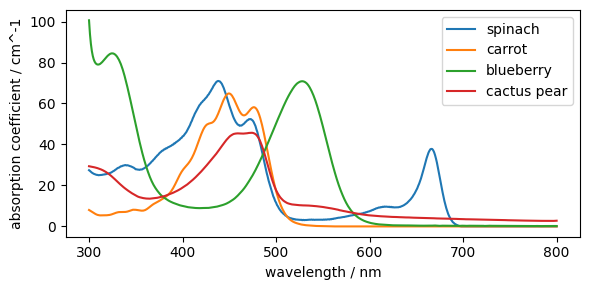

In [7]:
fig, ax = plt.subplots(figsize=(6, 3))
for i in range(4):
    ax.plot(wavelengths, plant_absorption[:, i], label=PLANT_LABELS[i])
ax.set_xlabel('wavelength / nm')
ax.set_ylabel('absorption coefficient / cm^-1')
ax.legend()
fig.tight_layout()
plt.show()


Now we mix a smoothie and synthesise its spectrum. In this simplified model, the absorption coefficient of the smoothie is a linear combination of the pure component spectra:

$$
\alpha_{\mathrm{smoothie}}(\lambda)
= c_1\alpha_{\mathrm{spinach}}(\lambda)
+ c_2\alpha_{\mathrm{carrot}}(\lambda)
+ c_3\alpha_{\mathrm{blueberry}}(\lambda)
+ c_4\alpha_{\mathrm{cactus\ pear}}(\lambda)\,.
$$

Here, $\alpha(\lambda)$ denotes the absorption coefficient at wavelength $\lambda$. The unknowns are the ingredient fractions $c_i$. Each measured wavelength gives one linear equation.


For this example, we choose a smoothie that contains a little spinach, carrot, blueberry, and cactus pear. The code below constructs the noiseless smoothie spectrum by adding the four plant spectra with these weights.


In [8]:
PLANT_FRACTIONS = np.array([0.25, 0.20, 0.35, 0.20])

alpha_smoothie_nl = np.zeros_like(wavelengths)
for i, frac in enumerate(PLANT_FRACTIONS):
    alpha_smoothie_nl += frac * plant_absorption[:, i]


Real measurements are never perfectly noise-free. To mimic this, we add normally distributed random noise to the synthetic smoothie spectrum. The suffix `_nl` in `alpha_smoothie_nl` stands for noiseless.


In [9]:
rng = np.random.default_rng(42)
noise = rng.normal(loc=0.0, scale=0.30, size=alpha_smoothie_nl.shape)
alpha_smoothie = alpha_smoothie_nl + noise

### Overdetermined System

First, we try to recover the ingredient fractions using the entire spectral range. The linear system is

$$
\begin{align*}
c_1\alpha_{\mathrm{spinach}}(\lambda_0)
+ c_2\alpha_{\mathrm{carrot}}(\lambda_0)
+ c_3\alpha_{\mathrm{blueberry}}(\lambda_0)
+ c_4\alpha_{\mathrm{cactus\ pear}}(\lambda_0)
&= \alpha_{\mathrm{smoothie}}(\lambda_0) \\
c_1\alpha_{\mathrm{spinach}}(\lambda_1)
+ c_2\alpha_{\mathrm{carrot}}(\lambda_1)
+ c_3\alpha_{\mathrm{blueberry}}(\lambda_1)
+ c_4\alpha_{\mathrm{cactus\ pear}}(\lambda_1)
&= \alpha_{\mathrm{smoothie}}(\lambda_1) \\
&\hspace*{1.25ex}\vdots \\
c_1\alpha_{\mathrm{spinach}}(\lambda_{500})
+ c_2\alpha_{\mathrm{carrot}}(\lambda_{500})
+ c_3\alpha_{\mathrm{blueberry}}(\lambda_{500})
+ c_4\alpha_{\mathrm{cactus\ pear}}(\lambda_{500})
&= \alpha_{\mathrm{smoothie}}(\lambda_{500})\,.
\end{align*}
$$

In matrix notation, this is

$$
\underbrace{
\begin{bmatrix}
\alpha_{\mathrm{spinach}}(\lambda_0) & \alpha_{\mathrm{carrot}}(\lambda_0) & \alpha_{\mathrm{blueberry}}(\lambda_0) & \alpha_{\mathrm{cactus\ pear}}(\lambda_0) \\
\alpha_{\mathrm{spinach}}(\lambda_1) & \alpha_{\mathrm{carrot}}(\lambda_1) & \alpha_{\mathrm{blueberry}}(\lambda_1) & \alpha_{\mathrm{cactus\ pear}}(\lambda_1) \\
\vdots & \vdots & \vdots & \vdots \\
\alpha_{\mathrm{spinach}}(\lambda_{500}) & \alpha_{\mathrm{carrot}}(\lambda_{500}) & \alpha_{\mathrm{blueberry}}(\lambda_{500}) & \alpha_{\mathrm{cactus\ pear}}(\lambda_{500})
\end{bmatrix}}_{\bm{A}}
\underbrace{
\begin{bmatrix}
c_1 \\
c_2 \\
c_3 \\
c_4
\end{bmatrix}}_{\vec{x}}
=
\underbrace{
\begin{bmatrix}
\alpha_{\mathrm{smoothie}}(\lambda_0) \\
\alpha_{\mathrm{smoothie}}(\lambda_1) \\
\vdots \\
\alpha_{\mathrm{smoothie}}(\lambda_{500})
\end{bmatrix}}_{\vec{b}}\,.
$$

For measurements at 501 wavelengths, we have 501 equations for only 4 unknown fractions. Because we added random noise, these equations are not exactly consistent. The system is therefore overdetermined, and the MP inverse gives the least-squares composition.


In [10]:
c_over = mp_inverse(plant_absorption) @ alpha_smoothie
print('True fractions:', PLANT_FRACTIONS)
print('Estimated fractions:', c_over)

True fractions: [0.25 0.2  0.35 0.2 ]
Estimated fractions: [0.250126   0.19839956 0.34955849 0.20192294]


The coefficient matrix is `plant_absorption`, and the right-hand side is the noisy smoothie spectrum `alpha_smoothie`. Multiplying the MP inverse of the coefficient matrix with the measured spectrum gives the estimated ingredient fractions. We then reconstruct the fitted spectrum from these fractions and quantify the agreement with the mean squared error (MSE).


In [11]:
fit_smoothie = plant_absorption @ c_over
mse_measured = np.mean((fit_smoothie - alpha_smoothie) ** 2)
mse_noiseless = np.mean((fit_smoothie - alpha_smoothie_nl) ** 2)

print('MSE(fitted, measured): ', mse_measured)
print('MSE(fitted, noiseless):', mse_noiseless)

MSE(fitted, measured):  0.08286447580926455
MSE(fitted, noiseless): 8.670106450558342e-05


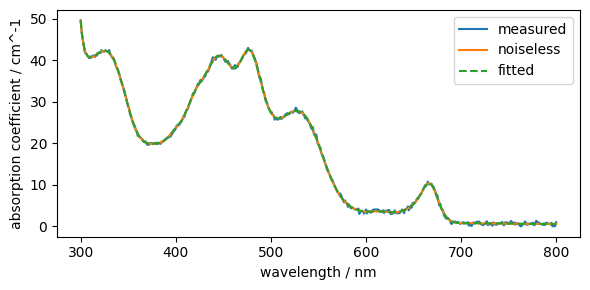

In [12]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(wavelengths, alpha_smoothie, label='measured')
ax.plot(wavelengths, alpha_smoothie_nl, label='noiseless')
ax.plot(wavelengths, fit_smoothie, '--', label='fitted')
ax.set_xlabel('wavelength / nm')
ax.set_ylabel('absorption coefficient / cm^-1')
ax.legend()
fig.tight_layout()
plt.show()

The estimated fractions are close to the true fractions. More importantly, 
the fitted spectrum follows the measured spectrum over the whole wavelength range. 
It does not pass through every noisy data point exactly, and it should not: 
the least-squares solution balances the residuals across all wavelengths.

The MSE values show this quantitatively. 
The fitted spectrum is close to the noisy measured spectrum, 
but it is even closer to the noiseless spectrum from which the data were generated. 
This is the main advantage of using the full spectrum. 
A single wavelength can be selective, but a whole spectrum carries a richer fingerprint 
of the mixture. When many wavelength points are used at once, randomly distributed noise 
can partly average out, so the composition estimate becomes more robust than it would be 
from only one or two measurements.

Now suppose you find yourself in the perfectly realistic experimental situation
that your experimental planning has proceeded in the usual optimistic way:
the smoothie took longer than expected, the guests are arriving, and there is
time for exactly two wavelength measurements before social consequences set in.

### Underdetermined System

With just two wavelength measurements, the system becomes

$$
\begin{align*}
c_1\alpha_{\mathrm{spinach}}(\lambda_i)
+ c_2\alpha_{\mathrm{carrot}}(\lambda_i)
+ c_3\alpha_{\mathrm{blueberry}}(\lambda_i)
+ c_4\alpha_{\mathrm{cactus\ pear}}(\lambda_i)
&= \alpha_{\mathrm{smoothie}}(\lambda_i) \\
c_1\alpha_{\mathrm{spinach}}(\lambda_j)
+ c_2\alpha_{\mathrm{carrot}}(\lambda_j)
+ c_3\alpha_{\mathrm{blueberry}}(\lambda_j)
+ c_4\alpha_{\mathrm{cactus\ pear}}(\lambda_j)
&= \alpha_{\mathrm{smoothie}}(\lambda_j)\,.
\end{align*}
$$

In matrix notation, this is

$$
\underbrace{\begin{bmatrix}
\alpha_{\mathrm{spinach}}(\lambda_i) & \alpha_{\mathrm{carrot}}(\lambda_i) & \alpha_{\mathrm{blueberry}}(\lambda_i) & \alpha_{\mathrm{cactus\ pear}}(\lambda_i) \\
\alpha_{\mathrm{spinach}}(\lambda_j) & \alpha_{\mathrm{carrot}}(\lambda_j) & \alpha_{\mathrm{blueberry}}(\lambda_j) & \alpha_{\mathrm{cactus\ pear}}(\lambda_j)
\end{bmatrix}}_{\bm{A}}
\underbrace{\begin{bmatrix}
c_1 \\ c_2 \\ c_3 \\ c_4
\end{bmatrix}}_{\vec{x}}
=
\underbrace{\begin{bmatrix}
\alpha_{\mathrm{smoothie}}(\lambda_i) \\ \alpha_{\mathrm{smoothie}}(\lambda_j)
\end{bmatrix}}_{\vec{b}}\,.
$$

The system is underdetermined. There are infinitely many compositions that
match these two noisy absorbance measurements exactly. 
Therefore, the MP inverse gives us the minimum-norm solution.

For this example, we choose to measure at $\lambda_i=440\,\mathrm{nm}$ and $\lambda_j=550\,\mathrm{nm}$.

In [13]:
lambda_i = 440.0
lambda_j = 550.0
index_i = np.argmin(np.abs(wavelengths - lambda_i))
index_j = np.argmin(np.abs(wavelengths - lambda_j))
selected_indices = [index_i, index_j]

a_under = plant_absorption[selected_indices, :]
b_under = alpha_smoothie[selected_indices]

c_under = np.linalg.pinv(a_under) @ b_under
print('Selected wavelengths:', wavelengths[selected_indices])
print('True fractions:', PLANT_FRACTIONS)
print('Estimated fractions:', c_under)

Selected wavelengths: [440. 550.]
True fractions: [0.25 0.2  0.35 0.2 ]
Estimated fractions: [0.26112079 0.19521916 0.34895398 0.19002916]


The code first translates the chosen wavelengths into row indices of the data
array. The expression `np.abs(wavelengths - lambda_i)` gives the distance
between every available wavelength and the requested wavelength `lambda_i`.
`np.argmin(...)` then returns the index of the smallest distance, so `index_i`
points to the measured wavelength that is closest to `lambda_i`. The same is
done for `lambda_j`.

With these two indices, we select the corresponding rows from the pure-component
spectra to build `a_under`, and the two measured smoothie absorbances to build
`b_under`. The pseudoinverse then gives the minimum-norm solution for this
underdetermined two-equation system.


The result exactly reproduces the two noisy measurements. 
In this case, the estimate is quite close to the true composition.
That is not a general guarantee. The pseudoinverse has selected one solution
from a whole family of exact solutions, and another pair of wavelengths could
lead to a much less useful, or even unphysical, composition estimate.
In particular, the estimated fractions are not guaranteed to be non-negative or 
to sum to one, which are common constraints in compositional analysis.

The following interactive plot lets us explore this idea. The two vertical lines
represent the two measurement wavelengths. 
You can drag them to change the wavelengths at which the measurements are taken.
The sliders define the ingredient fractions. When one slider is changed, the
other three are adjusted proportionally so that the fractions always sum to 1.0.
The smoothie spectrum and the two readouts are then recalculated from this
composition.

In [14]:
import json
from IPython.display import HTML

widget_id = 'smoothie-widget-linear-systems'
widget_payload = {
    'wavelengths': wavelengths.tolist(),
    'plants': PLANT_LABELS,
    'spectra': {name: plant_absorption[:, i].tolist() for i, name in enumerate(PLANT_LABELS)},
    'initialWeights': dict(zip(PLANT_LABELS, PLANT_FRACTIONS)),
    'initialWavelengths': wavelengths[selected_indices].tolist(),
}

html = """
<div id="{widget_id}" class="smoothie-widget"></div>
<script type="application/json" id="{widget_id}-data">
{payload}
</script>
<script>
(() => {{
  const root = document.getElementById('{widget_id}');
  if (!root || root.dataset.ready === 'true') return;
  root.dataset.ready = 'true';

  const payload = JSON.parse(document.getElementById('{widget_id}-data').textContent);
  const wavelengths = payload.wavelengths;
  const plants = payload.plants;
  const spectra = payload.spectra;
  const colors = {{
    'spinach': '#618661',
    'carrot': '#e18900',
    'blueberry': '#492581',
    'cactus pear': '#a89942',
    'smoothie': '#222222'
  }};

  const state = {{
    lambda: [payload.initialWavelengths[0], payload.initialWavelengths[1]],
    weights: {{ ...payload.initialWeights }},
    dragging: null
  }};

  const margin = {{ left: 30, right: 20 }};
  const panelWidth = 700;
  const panelHeight = 80;
  const outerTopMargin = 10;
  const outerBottomMargin = 35;
  const panelGap = 15;
  const sliderHeight = 10;
  const nPanels = 5;
  const totalHeight = outerTopMargin + nPanels * panelHeight + (nPanels - 1) * panelGap + outerBottomMargin + sliderHeight;
  const minWavelength = wavelengths[0];
  const maxWavelength = wavelengths[wavelengths.length - 1];
  const maxAbsorbance = Math.max(...plants.flatMap(name => spectra[name]));

  root.innerHTML = `
    <style>
      .jp-RenderedHTMLCommon.jp-RenderedHTML.jp-mod-trusted.jp-OutputArea-output:has(.smoothie-widget) {{
        padding-right: 0 !important;
      }}
      #{widget_id} {{
        width: 100%;
        max-width: 700px;
        margin: 0.5rem auto 1rem auto;
        font-family: system-ui, -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif;
      }}
      #{widget_id} svg {{
        width: 100%;
        height: auto;
        display: block;
        border: 1px solid #d9dde3;
        background: white;
      }}
      #{widget_id} .axis {{ stroke: #1f2933; stroke-width: 1; }}
      #{widget_id} .spectrum-path {{ fill: none; stroke-width: 2; }}
      #{widget_id} .lambda-line {{ stroke-width: 2.4; cursor: ew-resize; }}
      #{widget_id} .lambda-hit {{ stroke: transparent; stroke-width: 16; cursor: ew-resize; }}
      #{widget_id} .panel-label {{ font-size: 16px; font-weight: 600; text-anchor: end; }}
      #{widget_id} .axis-label {{ font-size: 14px; fill: #52606d; text-anchor: middle; }}
      #{widget_id} .tick-label {{ font-size: 14px; fill: #52606d; text-anchor: middle; }}
      #{widget_id} .slider-row {{ display: grid; grid-template-columns: 92px minmax(120px, 1fr) 58px; gap: 10px; align-items: center; }}
      #{widget_id} .slider-row label {{ font-size: 14px; color: #1f2933; }}
      #{widget_id} .slider-row input[type="range"] {{ width: 100%; accent-color: #0b5fff; }}
      #{widget_id} .slider-row output {{ font-variant-numeric: tabular-nums; color: #1f2933; text-align: right; }}
      #{widget_id} .readouts {{ display: grid; grid-template-columns: repeat(2, minmax(0, 1fr)) auto; gap: 12px; margin-top: 10px; align-items: stretch; }}
      #{widget_id} .readout-box {{ width: 100%; box-sizing: border-box; border: 1px solid #cbd2d9; border-radius: 4px; padding: 7px 9px; font-size: 14px; font-variant-numeric: tabular-nums; background: #f8fafc; color: #1f2933; min-height: 36px; display: flex; align-items: center; }}
      #{widget_id} .reset-button {{ border: 1px solid #cbd2d9; border-radius: 4px; padding: 7px 12px; font-size: 14px; background: #ffffff; color: #1f2933; cursor: pointer; }}
      #{widget_id} .reset-button:hover {{ background: #f1f5f9; }}
      #{widget_id} .hint {{ font-size: 12px; fill: #52606d; }}
    </style>
    <svg viewBox="0 0 ${{panelWidth}} ${{totalHeight}}" role="img" aria-label="Interactive smoothie spectra with draggable wavelength lines"></svg>
  `;

  const svg = root.querySelector('svg');
  const ns = 'http://www.w3.org/2000/svg';

  function el(name, attrs = {{}}, parent = svg) {{
    const node = document.createElementNS(ns, name);
    Object.entries(attrs).forEach(([key, value]) => node.setAttribute(key, value));
    parent.appendChild(node);
    return node;
  }}

  function xScale(lambda) {{
    return margin.left + (lambda - minWavelength) / (maxWavelength - minWavelength) * (panelWidth - margin.left - margin.right);
  }}

  function yScale(value, plotTop, ymax) {{
    return plotTop + panelHeight - value / ymax * panelHeight;
  }}

  function lambdaFromSvgX(x) {{
    const frac = (x - margin.left) / (panelWidth - margin.left - margin.right);
    const lambda = minWavelength + frac * (maxWavelength - minWavelength);
    return Math.round(Math.max(minWavelength, Math.min(maxWavelength, lambda)));
  }}

  function clampDraggedLambda(which, lambda) {{
    if (which === 0) {{
      return Math.min(lambda, state.lambda[1] - 1);
    }}
    return Math.max(lambda, state.lambda[0] + 1);
  }}

  function normalisedFractions() {{
    const total = plants.reduce((acc, name) => acc + Number(state.weights[name]), 0);
    if (total <= 0) return Object.fromEntries(plants.map(name => [name, 1 / plants.length]));
    return Object.fromEntries(plants.map(name => [name, Number(state.weights[name]) / total]));
  }}

  function setLinkedFraction(changedName, requestedValue) {{
    const value = Math.max(0, Math.min(1, Number(requestedValue)));
    const otherNames = plants.filter(name => name !== changedName);
    const otherTotal = otherNames.reduce((acc, name) => acc + Number(state.weights[name]), 0);
    const remaining = 1 - value;

    state.weights[changedName] = value;
    if (otherTotal > 0) {{
      otherNames.forEach(name => {{
        state.weights[name] = remaining * Number(state.weights[name]) / otherTotal;
      }});
    }} else {{
      otherNames.forEach(name => {{
        state.weights[name] = remaining / otherNames.length;
      }});
    }}
  }}

  function smoothieSpectrum() {{
    const fractions = normalisedFractions();
    return wavelengths.map((_, i) => plants.reduce((acc, name) => acc + fractions[name] * spectra[name][i], 0));
  }}

  function valueAt(values, lambda) {{
    const i = Math.max(0, Math.min(values.length - 1, Math.round(lambda) - minWavelength));
    return values[i];
  }}

  function pathFor(values, panelTop, ymax) {{
    return wavelengths.map((lambda, i) => `${{i === 0 ? 'M' : 'L'}} ${{xScale(lambda).toFixed(2)}} ${{yScale(values[i], panelTop, ymax).toFixed(2)}}`).join(' ');
  }}

  const panels = [
    {{ name: 'smoothie', values: smoothieSpectrum, ymax: maxAbsorbance }},
    ...plants.map(name => ({{ name, values: () => spectra[name], ymax: maxAbsorbance }}))
  ];

  const lineNodes = [[], []];
  const hitNodes = [[], []];
  const pathNodes = [];

  panels.forEach((panel, panelIndex) => {{
    const plotTop = outerTopMargin + panelIndex * (panelHeight + panelGap);
    const plotBottom = plotTop + panelHeight;
    const plotLeft = margin.left;
    const plotRight = panelWidth - margin.right;

    el('line', {{ x1: plotLeft, y1: plotBottom, x2: plotRight, y2: plotBottom, class: 'axis' }});
    el('line', {{ x1: plotLeft, y1: plotTop, x2: plotLeft, y2: plotBottom, class: 'axis' }});
    pathNodes.push(el('path', {{ class: 'spectrum-path', stroke: colors[panel.name] || '#333' }}));
    el('text', {{ x: plotRight - 4, y: plotTop + 10, class: 'panel-label', fill: colors[panel.name] || '#333' }}).textContent = panel.name;
    [300, 400, 500, 600, 700, 800].forEach(lambda => {{
      const x = xScale(lambda);
      el('line', {{ x1: x, y1: plotBottom, x2: x, y2: plotBottom + 4, class: 'axis' }});
      if (panelIndex === panels.length - 1) {{
        el('text', {{ x, y: plotBottom + 20, class: 'tick-label' }}).textContent = lambda;
      }}
    }});
    if (panelIndex === panels.length - 1) {{
      el('text', {{ x: (plotLeft + plotRight) / 2, y: plotBottom + 35, class: 'tick-label' }}).textContent = 'wavelength / nm';
    }}

    [0, 1].forEach(which => {{
      const color = which === 0 ? '#0b5fff' : '#d9480f';
      const line = el('line', {{ y1: plotTop, y2: plotBottom, class: 'lambda-line', stroke: color }});
      const hit = el('line', {{ y1: plotTop, y2: plotBottom, class: 'lambda-hit' }});
      lineNodes[which].push(line);
      hitNodes[which].push(hit);
      [line, hit].forEach(node => node.addEventListener('pointerdown', event => {{
        state.dragging = which;
        svg.setPointerCapture(event.pointerId);
        event.preventDefault();
      }}));
    }});
  }});

  const yLabelCenter = outerTopMargin + (nPanels * panelHeight + (nPanels - 1) * panelGap) / 2;
  el('text', {{ x: 18, y: yLabelCenter, transform: `rotate(-90 18 ${{yLabelCenter}})`, class: 'axis-label' }}).textContent = 'absorption coefficient';
  
  const controls = document.createElement('div');
  controls.style.marginTop = '12px';
  controls.innerHTML = plants.map(name => `
    <div class="slider-row">
      <label for="{widget_id}-${{name.replaceAll(' ', '-')}}">${{name}}</label>
      <input id="{widget_id}-${{name.replaceAll(' ', '-')}}" type="range" min="0" max="1" step="0.01" value="${{state.weights[name]}}" data-plant="${{name}}">
      <output data-output="${{name}}"></output>
    </div>
  `).join('') + `
    <div class="readouts">
      <div class="readout-box" data-readout="0" role="status" aria-live="polite" aria-label="Absorbance at first wavelength"></div>
      <div class="readout-box" data-readout="1" role="status" aria-live="polite" aria-label="Absorbance at second wavelength"></div>
      <button type="button" class="reset-button">Reset</button>
    </div>
  `;
  root.appendChild(controls);

  controls.querySelectorAll('input[type="range"]').forEach(input => {{
    input.addEventListener('input', () => {{
      setLinkedFraction(input.dataset.plant, input.value);
      render();
    }});
  }});

  controls.querySelector('.reset-button').addEventListener('click', () => {{
    state.lambda = [payload.initialWavelengths[0], payload.initialWavelengths[1]];
    state.weights = {{ ...payload.initialWeights }};
    render();
  }});

  svg.addEventListener('pointermove', event => {{
    if (state.dragging === null) return;
    const point = svg.createSVGPoint();
    point.x = event.clientX;
    point.y = event.clientY;
    const svgPoint = point.matrixTransform(svg.getScreenCTM().inverse());
    state.lambda[state.dragging] = clampDraggedLambda(state.dragging, lambdaFromSvgX(svgPoint.x));
    render();
  }});
  svg.addEventListener('pointerup', () => {{ state.dragging = null; }});
  svg.addEventListener('pointerleave', () => {{ state.dragging = null; }});

  function render() {{
    const smoothie = smoothieSpectrum();
    panels[0].values = () => smoothie;

    panels.forEach((panel, panelIndex) => {{
      const plotTop = outerTopMargin + panelIndex * (panelHeight + panelGap);
      pathNodes[panelIndex].setAttribute('d', pathFor(panel.values(), plotTop, panel.ymax));
    }});

    [0, 1].forEach(which => {{
      const x = xScale(state.lambda[which]);
      lineNodes[which].forEach(line => {{ line.setAttribute('x1', x); line.setAttribute('x2', x); }});
      hitNodes[which].forEach(line => {{ line.setAttribute('x1', x); line.setAttribute('x2', x); }});
    }});

    const fractions = normalisedFractions();
    plants.forEach(name => {{
      const slider = controls.querySelector(`input[data-plant="${{name}}"]`);
      slider.value = fractions[name].toFixed(4);
      controls.querySelector(`[data-output="${{name}}"]`).textContent = `${{(100 * fractions[name]).toFixed(1)}} %`;
    }});

    [0, 1].forEach(which => {{
      const lambda = Math.round(state.lambda[which]);
      const absorbance = valueAt(smoothie, lambda);
      const subscript = which === 0 ? '₁' : '₂';
      controls.querySelector(`[data-readout="${{which}}"]`).textContent = `λ${{subscript}} = ${{lambda}} nm  α(λ${{subscript}}) = ${{absorbance.toFixed(3)}} cm⁻¹`;
    }});

  }}

  render();
}})();
</script>
""".format(widget_id=widget_id, payload=json.dumps(widget_payload))

HTML(html)


For a quick demonstration, we can choose another pair of wavelengths. The pair
305 nm and 573 nm is well separated, both wavelengths are below 700 nm, and the
smoothie has a clear absorbance signal at both points. Nevertheless, this pair
is not sufficient to determine a physically meaningful four-component
composition.


In [15]:
lambda_ip = 305.0
lambda_jp = 573.0

index_ip = np.argmin(np.abs(wavelengths - lambda_ip))
index_jp = np.argmin(np.abs(wavelengths - lambda_jp))
selected_indices_p = [index_ip, index_jp]

a_under_p = plant_absorption[selected_indices_p, :]
b_under_p = alpha_smoothie[selected_indices_p]

c_under_p = np.linalg.pinv(a_under_p) @ b_under_p

print('Selected wavelengths:', wavelengths[selected_indices_p], 'nm')
print('Estimated fractions:')
for label, fraction in zip(PLANT_LABELS, c_under_p):
    print(f'  {label:12s}: {fraction: .3f}')
print('Sum of fractions:', c_under_p.sum())

Selected wavelengths: [305. 573.] nm
Estimated fractions:
  spinach     :  0.144
  carrot      : -0.068
  blueberry   :  0.342
  cactus pear :  0.364
Sum of fractions: 0.7819961748102914


The solution reproduces the two selected measurements, but it is not a
meaningful smoothie composition. A negative carrot fraction is physically
impossible. This is not an algebraic error: the pseudoinverse solved the system
we gave it. The problem is that two noisy measurements, without non-negativity
or sum-to-one constraints, do not contain enough information to determine four
physical composition fractions.


## Self-Study Questions

1. Suppose two rows of a coefficient matrix are exact multiples of each other.
   Why can this make the simple comparison of $m$ and $n$ misleading when
   deciding the determinacy of a linear system?
2. In the implementation of `mp_inverse`, what could go wrong if a very small
   singular value were inverted instead of being treated as zero?
3. Under which conditions can the fitted spectrum be closer to the true
   noiseless spectrum than to the noisy measured spectrum?
4. In an underdetermined system, many different vectors can reproduce the same
   measurements exactly. Why can the minimum-norm solution be different from the
   solution that satisfies additional chemical constraints, such as non-negative
   fractions and a sum of one?
5. For $\sum_i c_i = 1$ and $c_i \geq 0$, which fractions yield the smallest
   Euclidean norm? Do you expect the minimum-norm solution to work better or
   worse when the true composition is dominated by one ingredient?
